# <span style="color:red">  Monthly Data - EBC creation, FMB Quantiles (1970 -2024)

#### Import all our packages and functions

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


In [3]:
import importlib
import src.preference_factors.build_datasets as bd
import src.FamaMacBeth.betas as fmb_betas
import src.FamaMacBeth.pipeline as fmb_pipe
import src.FamaMacBeth.cross_sectional_regression as fmb_csr
import src.FamaMacBeth.pricing as fmb_pricing
import src.FamaMacBeth.backtest as fmb_backtest
import src.FamaMacBeth.plots as fmb_plots

# Reload the modules themselves
importlib.reload(bd)
importlib.reload(fmb_betas)
importlib.reload(fmb_pipe)
importlib.reload(fmb_csr)
importlib.reload(fmb_pricing)
importlib.reload(fmb_backtest)
importlib.reload(fmb_plots)


<module 'src.FamaMacBeth.plots' from '/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/plots.py'>

# <span style="color:red"> Create CSV's for Monthly EBC Weights, Beta Contributions, EBC returns, Preference Returns, Full preference and factors returns (Raw returns) </span>

In [4]:
merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

# Use raw (non-excess) EBC and CW-EBC spread
ebc = full_merged_df["EBC"]
cw_ebc = full_merged_df["CW"] - full_merged_df["EBC"]

Rolling OLS CAPM:   0%|          | 0/702 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/702 [00:00<?, ?it/s]

/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_EBC.py:261: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  weights_rebal = full_weights.resample("Q").last()


In [5]:
full_merged_df['MKT'] = full_merged_df['MKT_RF'] + full_merged_df['RF']

# <span style="color:red"> Get rolling betas for the two focus portfolios EBC and CW - EBC </span>

#### create factor returns

In [6]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

# Convert to timestamp to match asset_returns index
ebc.index = ebc.index.to_timestamp()
cw_ebc.index = cw_ebc.index.to_timestamp()

factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()

#### get asset returns (raw, no RF subtraction)

In [7]:
asset_returns, caps_df, ff_factors = fmb_pipe.load_monthly_inputs(DATA_RAW_DIR, excess= False)

#### compute rolling betas for EBc and CW-EBC

In [8]:
betas_ebc = fmb_betas.compute_rolling_betas(asset_returns, ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 702/702 [00:32<00:00, 21.28it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:74: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)


In [9]:
betas_cw_ebc = fmb_betas.compute_rolling_betas(asset_returns, cw_ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 702/702 [00:21<00:00, 32.67it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:74: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)


# <span style="color:red"> Equal Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [10]:
start_date = "1969-10-01"

## Filter all returns to match start date

In [11]:
asset_returns_trimmed = asset_returns.loc[start_date:]
caps_df_trimmed = caps_df.loc[start_date:]
factor_returns_trimmed = factor_returns.loc[start_date:]
betas_ebc_trimmed = betas_ebc.loc[start_date:]
betas_cw_ebc_trimmed = betas_cw_ebc.loc[start_date:]

In [12]:
n_q1, n_q2 = 3,3

In [13]:
#3,3

rename_map = {
    "Q1_Q1": "EBC_High_Pref_High",
    "Q1_Q2": "EBC_High_Pref_Mid",
    "Q1_Q3": "EBC_High_Pref_Low",
    "Q2_Q1": "EBC_Mid_Pref_High",
    "Q2_Q2": "EBC_Mid_Pref_Mid",
    "Q2_Q3": "EBC_Mid_Pref_Low",
    "Q3_Q1": "EBC_Low_Pref_High",
    "Q3_Q2": "EBC_Low_Pref_Mid",
    "Q3_Q3": "EBC_Low_Pref_Low",
}


In [14]:
if isinstance(full_merged_df.index, pd.PeriodIndex):
    full_merged_df.index = full_merged_df.index.to_timestamp(how="start")

In [15]:
selected_columns = ['CW',
                    'EBC_High_Pref_High', 'EBC_High_Pref_Mid', 'EBC_High_Pref_Low',
                    'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid', 'EBC_Mid_Pref_Low',
                    'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid', 'EBC_Low_Pref_Low']

In [16]:
period = start_date[:4] + '_2024'

In [17]:
ew_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ebc_trimmed,
    beta_CW_EBC_df=betas_cw_ebc_trimmed,
    returns_df=asset_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EBC"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EBC"],
    cap_weights=False,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'monthly',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC"
)

ew_results["mean_grid"]*12

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

,1,2,3
1,0.137276,0.147360,0.163512
2,0.126057,0.136589,0.150103
3,0.111751,0.126063,0.133316


In [18]:
rename_map = {
    "Q1_Q1": "EBC_High_Pref_High",
    "Q1_Q2": "EBC_High_Pref_Mid",
    "Q1_Q3": "EBC_High_Pref_Low",
    "Q2_Q1": "EBC_Mid_Pref_High",
    "Q2_Q2": "EBC_Mid_Pref_Mid",
    "Q2_Q3": "EBC_Mid_Pref_Low",
    "Q3_Q1": "EBC_Low_Pref_High",
    "Q3_Q2": "EBC_Low_Pref_Mid",
    "Q3_Q3": "EBC_Low_Pref_Low",
}

ew_portrets_raw = ew_results['portrets_wide'].copy()
ew_results['portrets_wide'] = ew_results['portrets_wide'].rename(columns=rename_map)


In [19]:
ew_complete_df = full_merged_df.join(
    ew_results['portrets_wide'],
    how="inner"
)

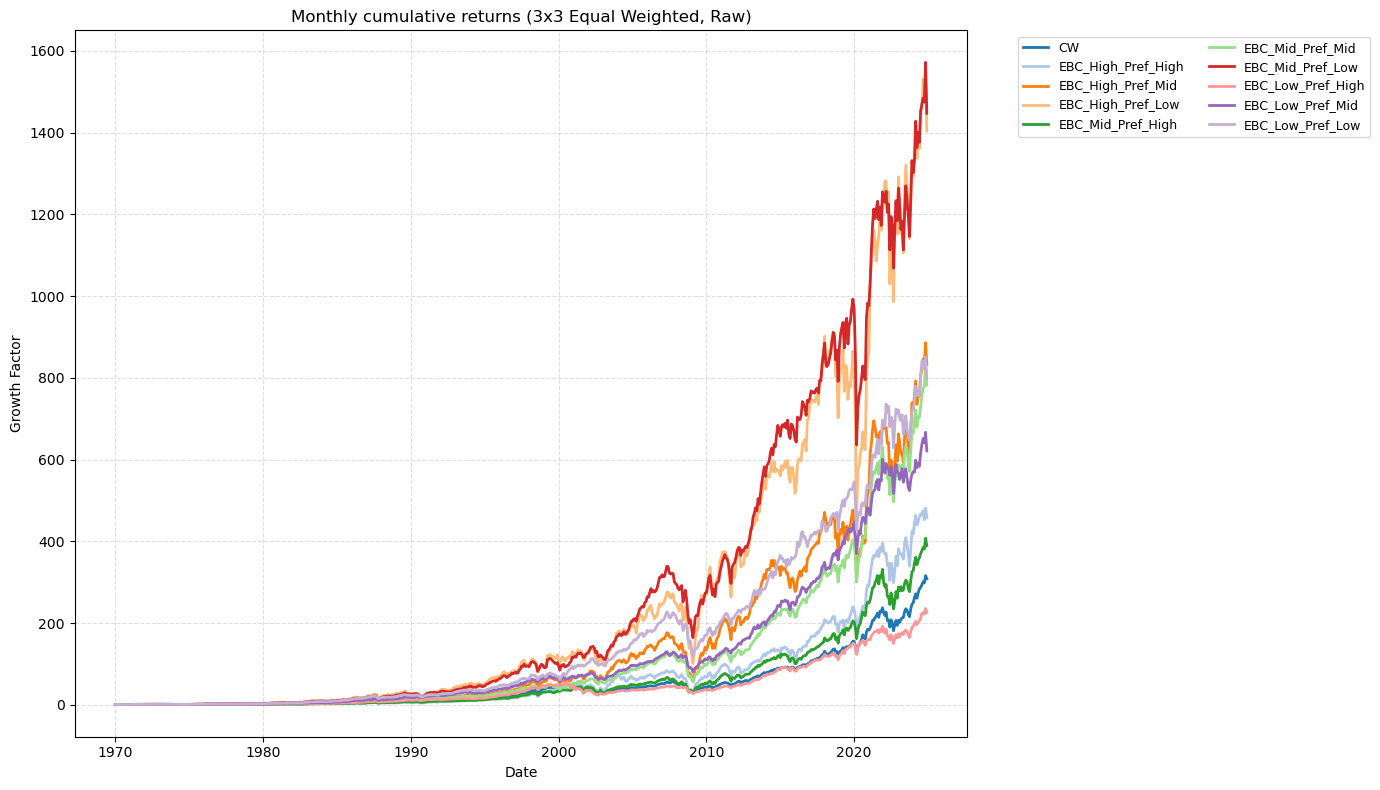

In [20]:
fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Monthly cumulative returns ({n_q1}x{n_q2} Equal Weighted, Raw)", log=False)

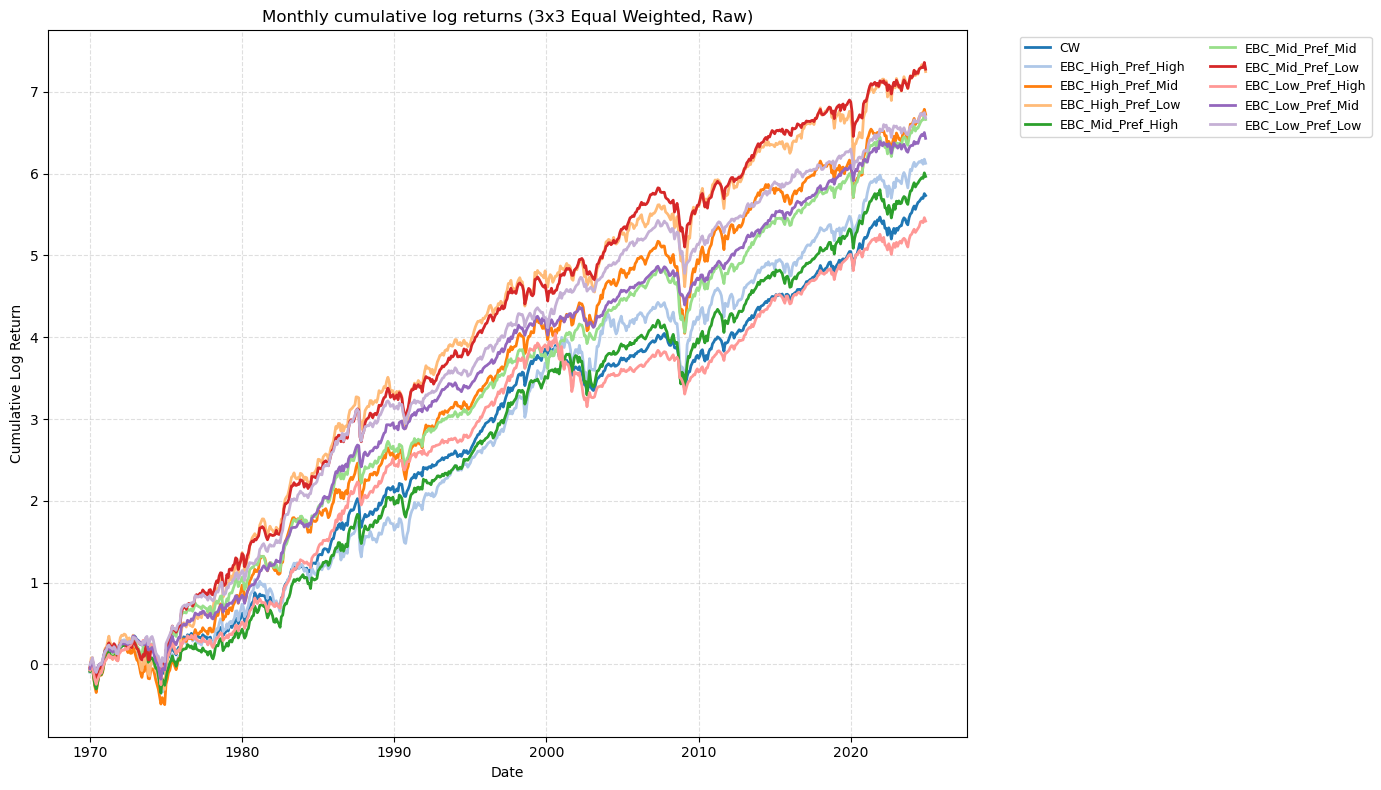

In [21]:
fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Monthly cumulative log returns ({n_q1}x{n_q2} Equal Weighted, Raw)",log = True)

In [22]:
monthly_ew_quantile_returns = ew_complete_df[selected_columns]

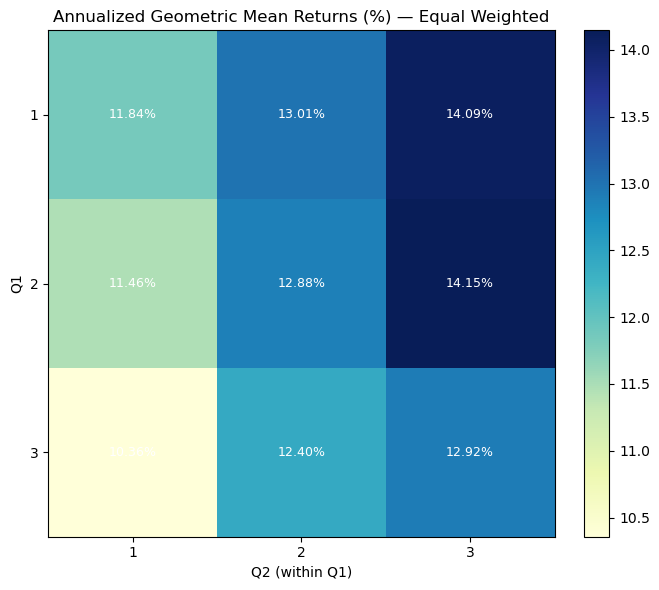

In [23]:
# True geometric mean grid (annualized as (1+geo_monthly)^12 − 1)
ew_actual_mean_grid = fmb_plots.plot_mean_grid_new(
    ew_results["mean_grid"], annualize=True, frequency='monthly', cw=False, geometric=True,
    portrets_wide=ew_portrets_raw
)

In [24]:
ew_actual_mean_grid

,1,2,3
1,11.840358,13.006214,14.085152
2,11.457197,12.877275,14.146548
3,10.356723,12.404934,12.915309


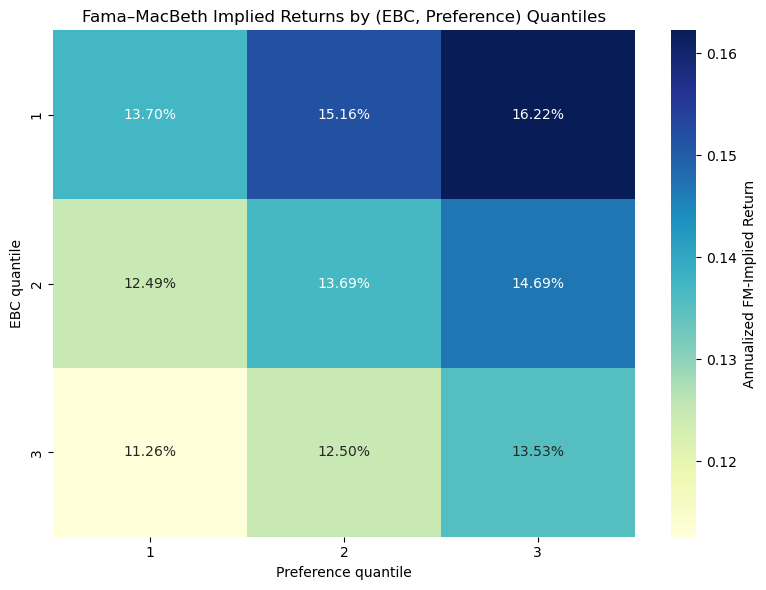

In [25]:
ew_implied_mean_grid = fmb_plots.plot_expected_return_grid(ew_results["pricing"], ew_results["fm_table"], n_q1, n_q2)

## Turnover

In [26]:
# ── Portfolio Turnover (Cap Weighted) ─────────────────────────────────────
members_cw = ew_results["members"].copy()
m = members_cw.reset_index()
m['period'] = m['date'].dt.to_period('Q')
first_date_per_period = m.groupby('period')['date'].min()
m_first = m[m['date'].isin(first_date_per_period.values)]

# Dynamic portfolio names derived from portrets_wide column order
_cw_cols = list(ew_results['portrets_wide'].columns)
portfolio_names = {
    (q1, q2): _cw_cols[(q1 - 1) * n_q2 + (q2 - 1)]
    for q1 in range(1, n_q1 + 1)
    for q2 in range(1, n_q2 + 1)
}

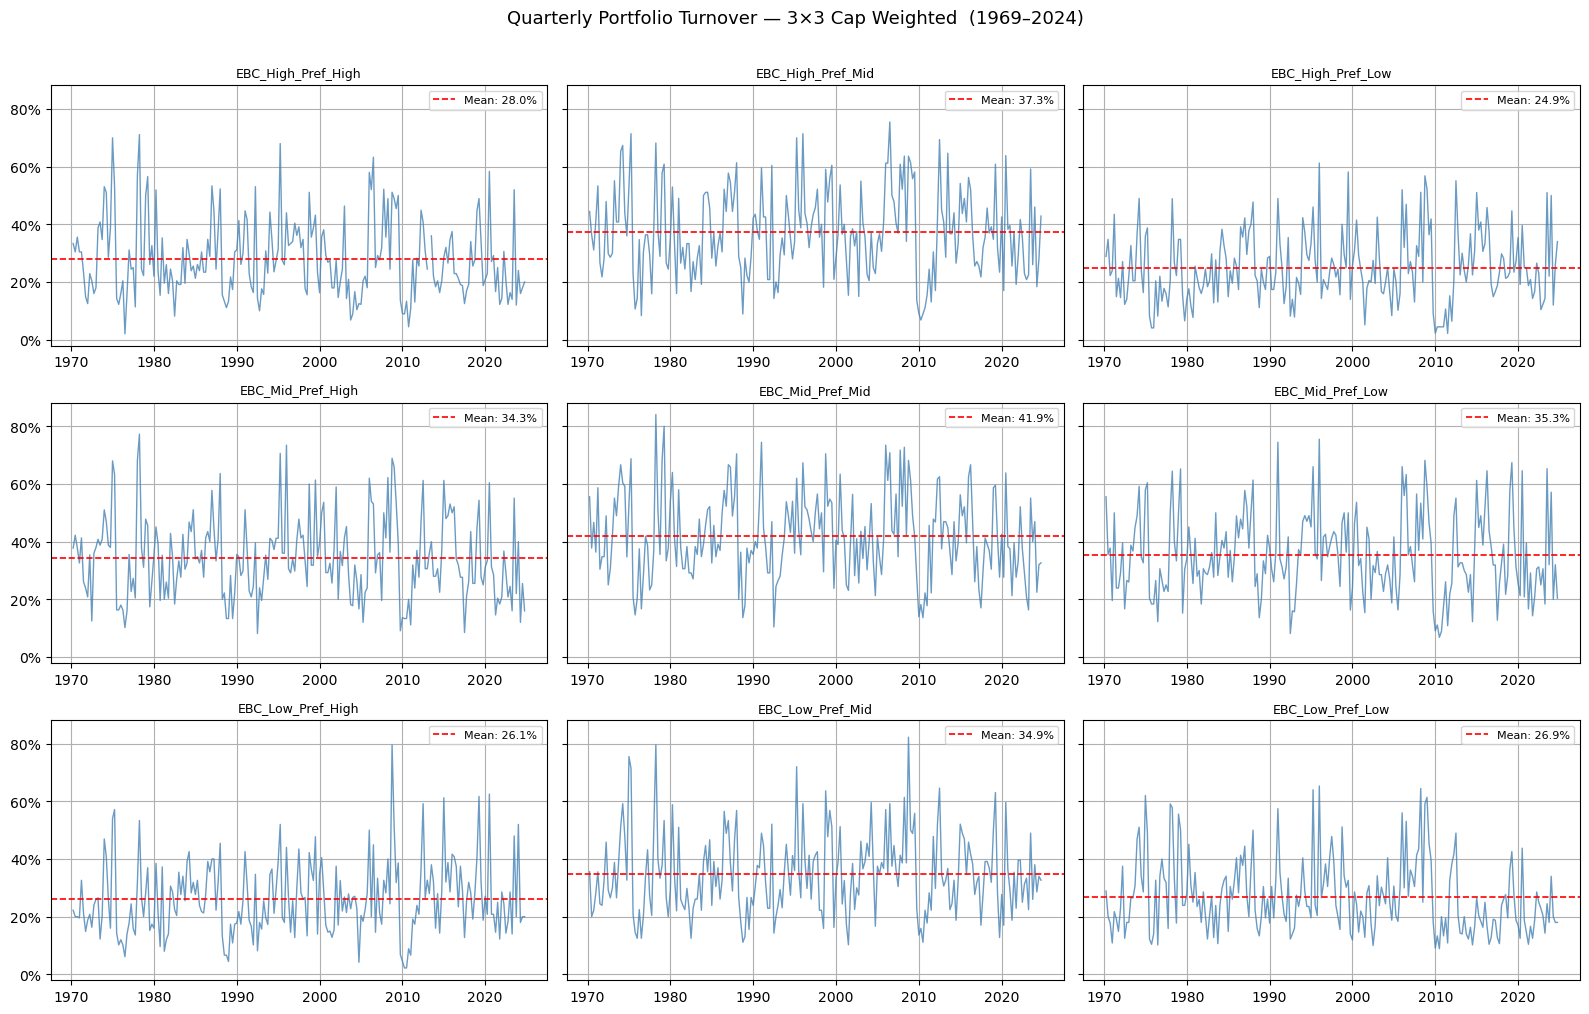

In [27]:
turnover_dict_cw = {}

for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_first[(m_first['q1'] == q1) & (m_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)

        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers

        turnover_dict_cw[portfolio_names[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_cw = pd.DataFrame(turnover_dict_cw)

# ── Plot: 3x3 grid ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=True)
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, turnover_cw.columns):
    avg = turnover_cw[col].mean()
    ax.plot(turnover_cw.index, turnover_cw[col], color='steelblue', linewidth=1, alpha=0.8)
    ax.axhline(avg, color='red', linestyle='--', linewidth=1.2, label=f"Mean: {avg:.1%}")
    ax.set_title(col, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle(
    f"Quarterly Portfolio Turnover — {n_q1}×{n_q2} Cap Weighted  ({period.replace('_', '–')})",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()



In [28]:

# ── Average turnover summary table ─────────────────────────────────────────
avg_to_cw = pd.DataFrame({
    "Avg Quarterly Turnover": turnover_cw.mean(),
    "Annualized Turnover":    turnover_cw.mean() * 4,
}).round(4)

print("Average Turnover by Portfolio Cell (Cap Weighted):")
display(avg_to_cw)

Average Turnover by Portfolio Cell (Cap Weighted):


,Avg Quarterly Turnover,Annualized Turnover
EBC_High_Pref_High,0.2799,1.1196
EBC_High_Pref_Mid,0.3726,1.4905
EBC_High_Pref_Low,0.2488,0.9954
EBC_Mid_Pref_High,0.3427,1.3706
EBC_Mid_Pref_Mid,0.4195,1.6778
EBC_Mid_Pref_Low,0.3527,1.4109
EBC_Low_Pref_High,0.2605,1.0421
EBC_Low_Pref_Mid,0.3486,1.3946
EBC_Low_Pref_Low,0.2692,1.0770


# <span style="color:red"> Transaction Costs — Quantile Portfolios </span>

**Formula (Invesco):** `TC = 2 × Turnover × 0.0005`

| Term | Meaning |
|---|---|
| `Turnover` | Fraction of holdings that *exit* a cell at each quarterly rebalancing |
| `0.0005` | One-way cost per dollar traded (5 bps: bid-ask spread + execution) |
| `× 2` | Round-trip: pay the spread to **sell** exiting stocks **and** to **buy** replacements |

Rebalancing is **quarterly**, so the cost is a one-time deduction applied in the **first month** of each new quarter. Non-rebalancing months are unaffected.

> To change the cost assumption, adjust `ONE_WAY_COST` below.

In [29]:
ONE_WAY_COST = 0.0005  # bps per side — change here to update everything below

# ── Step 1: EW turnover (from member assignments) ─────────────────────────
members_ew = ew_results["members"].copy()
m_ew = members_ew.reset_index()
m_ew['period'] = m_ew['date'].dt.to_period('Q')
first_date_per_period_ew = m_ew.groupby('period')['date'].min()
m_ew_first = m_ew[m_ew['date'].isin(first_date_per_period_ew.values)]

# Dynamic names derived from portrets_wide column order
_ew_cols = list(ew_results['portrets_wide'].columns)
portfolio_names_ew = {
    (q1, q2): _ew_cols[(q1 - 1) * n_q2 + (q2 - 1)]
    for q1 in range(1, n_q1 + 1)
    for q2 in range(1, n_q2 + 1)
}

turnover_dict_ew = {}
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_ew_first[(m_ew_first['q1'] == q1) & (m_ew_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)
        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers
        turnover_dict_ew[portfolio_names_ew[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_ew = pd.DataFrame(turnover_dict_ew)
turnover_ew_q = turnover_ew.copy()
turnover_ew_q.index = pd.DatetimeIndex(turnover_ew_q.index).to_period('Q')

# ── Step 2: Helper — map quarterly TC to first monthly return of each quarter
def build_tc_monthly(gross_df, turnover_q_df, one_way_cost):
    monthly_quarters = gross_df.index.to_period('Q')
    first_month_of_quarter = {}
    for date, q in zip(gross_df.index, monthly_quarters):
        if q not in first_month_of_quarter:
            first_month_of_quarter[q] = date
    tc = pd.DataFrame(0.0, index=gross_df.index, columns=gross_df.columns)
    for col in turnover_q_df.columns:
        if col not in tc.columns:
            continue
        for q_period, to_val in turnover_q_df[col].items():
            if q_period in first_month_of_quarter and not np.isnan(to_val):
                tc.loc[first_month_of_quarter[q_period], col] = 2 * to_val * one_way_cost
    return tc

# ── Step 3: Apply TC to both EW and CW portfolios ─────────────────────────
ew_gross = ew_results['portrets_wide'].copy()

ew_tc = build_tc_monthly(ew_gross, turnover_ew_q, ONE_WAY_COST)

ew_net = ew_gross - ew_tc

print(f"One-way cost : {ONE_WAY_COST*10_000:.1f} bps  |  Round-trip per 100% turnover: {2*ONE_WAY_COST*100:.2f}%")
print(f"\nMean quarterly TC per EW portfolio (bps):")
print((ew_tc[ew_tc > 0].mean() * 10_000).round(2).to_string())

One-way cost : 5.0 bps  |  Round-trip per 100% turnover: 0.10%

Mean quarterly TC per EW portfolio (bps):
EBC_High_Pref_High    2.80
EBC_High_Pref_Mid     3.73
EBC_High_Pref_Low     2.49
EBC_Mid_Pref_High     3.43
EBC_Mid_Pref_Mid      4.19
EBC_Mid_Pref_Low      3.53
EBC_Low_Pref_High     2.61
EBC_Low_Pref_Mid      3.49
EBC_Low_Pref_Low      2.69


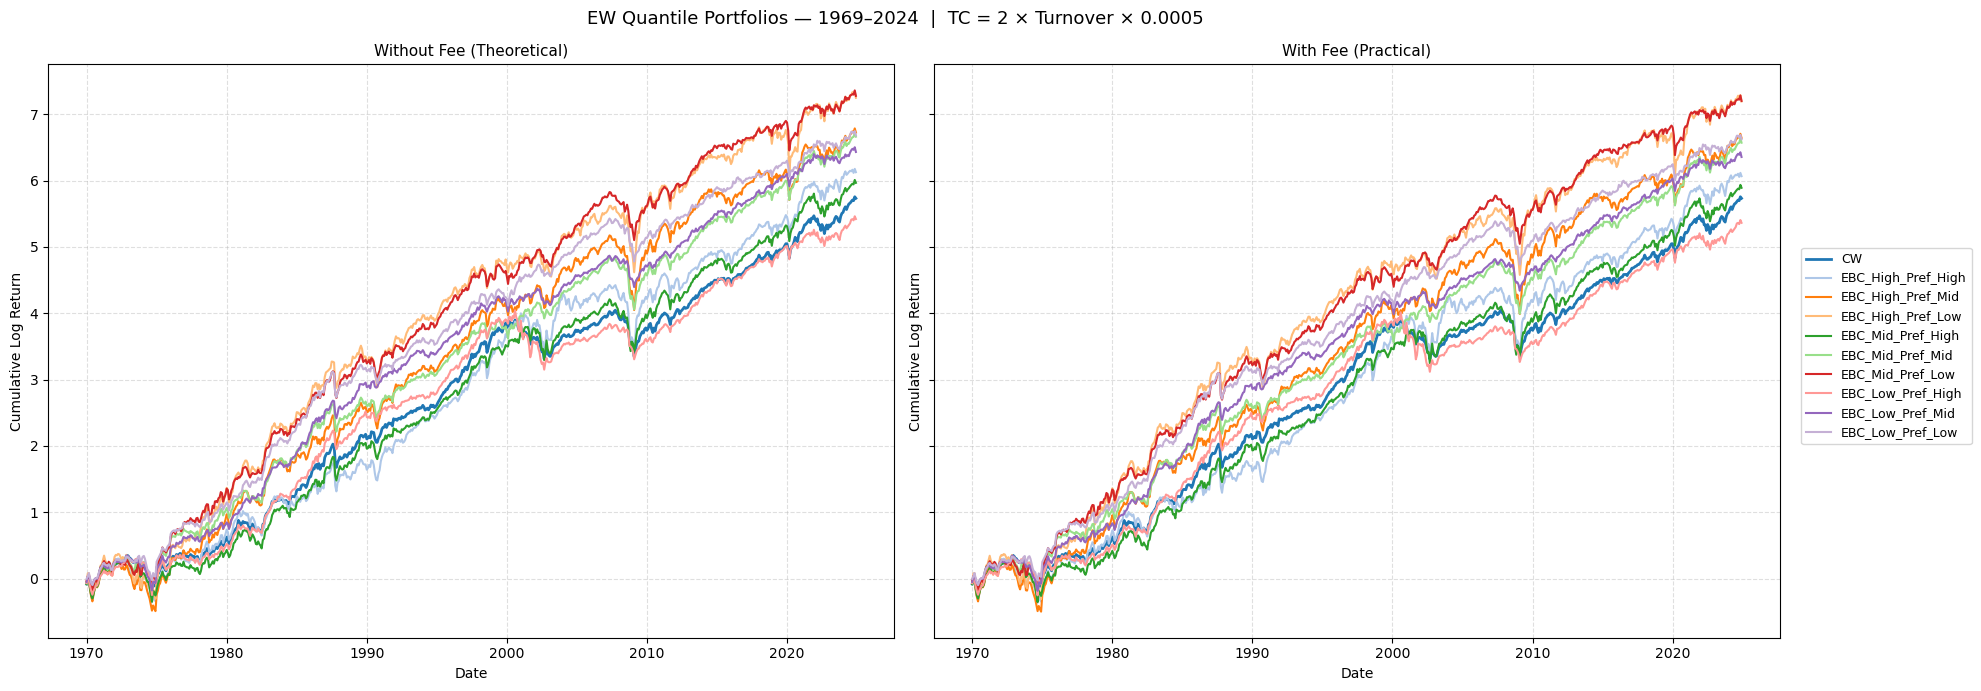

In [30]:
# ── Gross vs Net side-by-side (log cumulative returns) ────────────────────
# Left  = Without fee (theoretical)  |  Right = With fee (practical)

palette = plt.cm.tab20.colors
bench_color = palette[0]
port_colors = palette[1:10]

port_cols = list(ew_gross.columns)

bench = ew_complete_df['CW'].dropna()
bench_logcum = np.log1p(bench).cumsum()

def plot_gross_net_side_by_side(gross_df, net_df, bench_logcum, suptitle):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    for ax, df, subtitle in zip(axes,
                                [gross_df, net_df],
                                ["Without Fee (Theoretical)", "With Fee (Practical)"]):
        ax.plot(bench_logcum.index, bench_logcum.values,
                color=bench_color, linewidth=2, label='CW')
        for col, color in zip(port_cols, port_colors):
            lc = np.log1p(df[col].dropna()).cumsum()
            ax.plot(lc.index, lc.values, color=color, linewidth=1.5, label=col)
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative Log Return")
        ax.grid(True, linestyle='--', alpha=0.4)

    # Single shared legend to the right of both panels
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=1, fontsize=9,
               bbox_to_anchor=(1.0, 0.5), loc='center left')
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_gross_net_side_by_side(
    ew_gross, ew_net, bench_logcum,
    f"EW Quantile Portfolios — {period.replace('_','–')}  |  TC = 2 × Turnover × {ONE_WAY_COST}"
)

In [31]:
# ── Summary: Gross vs Net annualized geometric mean returns ───────────────
def tc_summary(gross_df, net_df, tc_df, label):
    rows = []
    for col in gross_df.columns:
        ann_gross = (1 + np.expm1(np.log1p(gross_df[col].dropna()).mean())) ** 12 - 1
        ann_net   = (1 + np.expm1(np.log1p(net_df[col].dropna()).mean())) ** 12 - 1
        avg_ann_tc = tc_df[col][tc_df[col] > 0].mean() * 4  # 4 quarters/year
        rows.append({
            "Portfolio": col.replace("EBC_", "").replace("_", " "),
            "Gross Ann.": f"{ann_gross:.2%}",
            "Net Ann.":   f"{ann_net:.2%}",
            "TC Drag (bps)": f"{(ann_gross - ann_net)*10_000:.1f}",
            "Avg Ann. TC (bps)": f"{avg_ann_tc*10_000:.1f}",
        })
    df = pd.DataFrame(rows).set_index("Portfolio")
    print(f"\n{'─'*60}")
    print(f"  {label}  |  {ONE_WAY_COST*10_000:.0f}bps/side  |  Formula: 2 × Turnover × {ONE_WAY_COST}")
    print(f"{'─'*60}")
    display(df)

tc_summary(ew_gross, ew_net, ew_tc, "EW Quantile Portfolios")


────────────────────────────────────────────────────────────
  EW Quantile Portfolios  |  5bps/side  |  Formula: 2 × Turnover × 0.0005
────────────────────────────────────────────────────────────


,Gross Ann.,Net Ann.,TC Drag (bps),Avg Ann. TC (bps)
Portfolio,,,,
High Pref High,11.84%,11.72%,12.3,11.2
High Pref Mid,13.01%,12.84%,16.6,14.9
High Pref Low,14.09%,13.97%,11.2,10.0
Mid Pref High,11.46%,11.31%,15.1,13.7
Mid Pref Mid,12.88%,12.69%,18.7,16.8
Mid Pref Low,14.15%,13.99%,15.9,14.1
Low Pref High,10.36%,10.24%,11.4,10.4
Low Pref Mid,12.40%,12.25%,15.5,13.9
Low Pref Low,12.92%,12.80%,12.0,10.8


In [32]:
'''
save_dir = DATA_PROCESSED_DIR / 'monthly'
ew_results['portrets_wide'].to_csv(save_dir / f"monthly_{period}_ebc_3x3_ew_quantile_returns.csv")
print(f"Saved: monthly_{period}_ebc_3x3_ew_quantile_returns.csv")
'''

Saved: monthly_1969_2024_ebc_3x3_ew_quantile_returns.csv
